In [5]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [6]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [7]:

train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


In [8]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [9]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [10]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

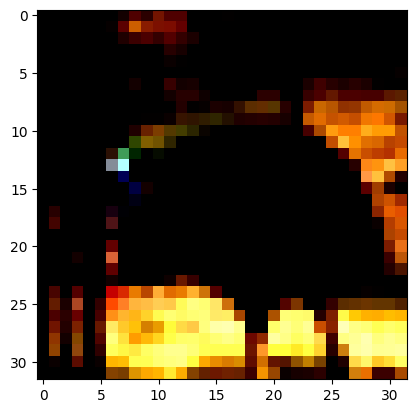

In [11]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [12]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [13]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [14]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [116]:
from numpy import corrcoef
class Trainer:
    def __init__(self, config, model, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

        self.val_accs = []
        self.val_loss = []
        self.train_accs = []
        self.train_loss = []


    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()
            self.val_accs.append(val_acc)
            self.val_loss.append(val_loss)
            self.train_accs.append(train_acc)
            self.train_loss.append(train_loss)

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)

        test_loss, test_acc, losses, accs = self.test()
        print(f'Test loss {test_loss}, test acc {test_acc}')
        return losses, accs, self.val_loss, self.val_accs, self.train_loss, self.train_accs



    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test(self):
      self.model.eval()


      total_loss = 0.0
      correct = 0
      total_samples = 0
      losses = []
      accs = []

      for images, labels in tqdm(self.test_loader):
        images, labels = images.to(self.device), labels.to(self.device)

        with torch.no_grad():
          outputs = self.model(images)
        loss = self.loss_function(outputs, labels)

        total_loss += loss.item()
        losses.append(loss.item())

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        accs.append(correct/total_samples * 100)

      total_loss  = total_loss / len(self.test_loader)
      test_acc = correct / total_samples * 100

      return total_loss, test_acc, losses, accs





In [117]:
trainer = Trainer(config, model=BasicCNN(), transform=transform)

In [118]:
losses_base, accs_base,  val_loss_base,  val_accs_base, train_loss_base,  train_accs_base = trainer.run()

100%|██████████| 79/79 [00:02<00:00, 29.09it/s]


Epoch 1 / 10 1.8007301728184613 1.5933059755759904 41.4


100%|██████████| 79/79 [00:03<00:00, 23.88it/s]


Epoch 2 / 10 1.5621484731332944 1.5606452588793598 43.44


100%|██████████| 79/79 [00:02<00:00, 28.59it/s]


...

Epoch 9 / 10 1.2924340083576238 1.3736954429481603 50.91


100%|██████████| 79/79 [00:02<00:00, 32.17it/s]


Epoch 10 / 10 1.2815697090313458 1.3711701344840135 50.88


100%|██████████| 79/79 [00:02<00:00, 31.33it/s]

Test loss 1.3702104302901257, test acc 51.31


# ResNet-18

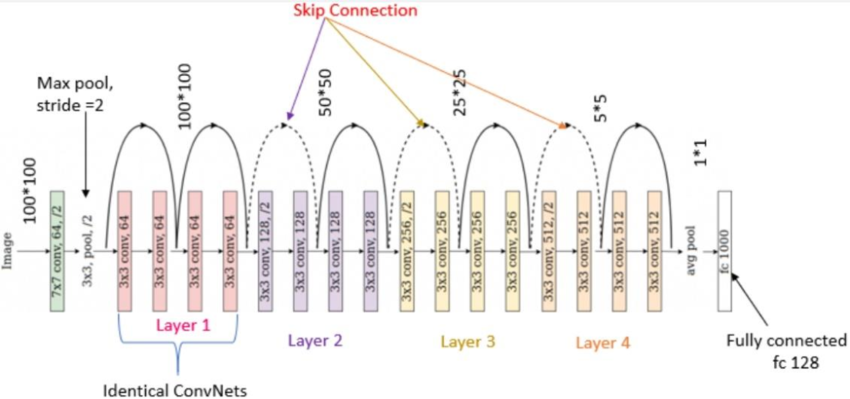

In [119]:
from torch.nn.modules.linear import Identity
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample):
        super().__init__()
        self.down = downsample
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(3,3) , stride=1, padding = 1)
        self.conv1_d = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=(3,3) , stride=2, padding = 1)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=(3,3), stride=1, padding = 1)
        self.relu = nn.GELU()
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.skip_d = nn.Sequential(
                          nn.Conv2d(in_channels, out_channels, kernel_size = (1,1), stride=2),
                          nn.BatchNorm2d(out_channels)

                     )
        self.skip = nn.Sequential(
                          nn.Conv2d(in_channels, out_channels, kernel_size = (1,1), stride=1),
                          nn.BatchNorm2d(out_channels)

                     )
    def forward(self, x):
        # Применить свертки + skip connection
        save = x
        if self.down:
          x = self.bn2(self.conv2(self.relu(self.bn1(self.conv1_d(x)))))
        else:
          x = self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x)))))

        if self.in_channels==self.out_channels:
          x = x + save
        elif self.down:
          x = x + self.skip_d(save)
        else:
          x = x + self.skip(save)
        out = self.relu(x)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.avg = nn.AdaptiveAvgPool2d(1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(64,128,2,False)
        self.layer2 = self.make_layer(128,256,2,True)
        self.layer3 = self.make_layer(256,512,2,True)
        self.layer4 = self.make_layer(512,512,2, False)

        self.fc = nn.Sequential(
            nn.Linear(512,64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64,num_classes)
        )
    def make_layer(self, in_channels, out_channels, blocks, downsample):
        layers = []
        if downsample:
          block = ResNetBlock(in_channels,out_channels,downsample=True)
          layers.append(block)
        else:
          block = ResNetBlock(in_channels,out_channels,downsample=False)
          layers.append(block)

        for block in range(blocks-1):
          block = ResNetBlock(out_channels,out_channels,downsample=False )
          layers.append(block)

        return nn.Sequential(*layers)

    def forward(self, x):

      # сделать forward pass
      x = self.max_pool(self.relu(self.bn1(self.conv1(x))))

      x = self.layer1(x)
      x = self.layer2(x)
      x = self.layer3(x)
      x = self.layer4(x)

      x = self.avg(x)
      x = self.flatten(x)

      out = self.fc(x)

      return out






$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [120]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN


trainer = Trainer(config, model=ResNet18(), transform=transform)

In [121]:
losses_res, accs_res,  val_loss,  val_accs, train_loss,  train_accs = trainer.run()

100%|██████████| 79/79 [00:04<00:00, 18.08it/s]


Epoch 1 / 10 1.9529185820692263 1.6222869006893303 36.84


100%|██████████| 79/79 [00:04<00:00, 16.74it/s]


Epoch 2 / 10 1.5519215615031818 1.5248309268227107 43.71


100%|██████████| 79/79 [00:04<00:00, 18.51it/s]


...

Epoch 9 / 10 0.5469548568938868 0.7383586432360396 75.11


100%|██████████| 79/79 [00:04<00:00, 18.63it/s]


Epoch 10 / 10 0.46775986954046134 0.7608528612535211 75.3


100%|██████████| 79/79 [00:04<00:00, 16.45it/s]

Test loss 0.7972985377794579, test acc 73.97


<function matplotlib.pyplot.show(close=None, block=None)>

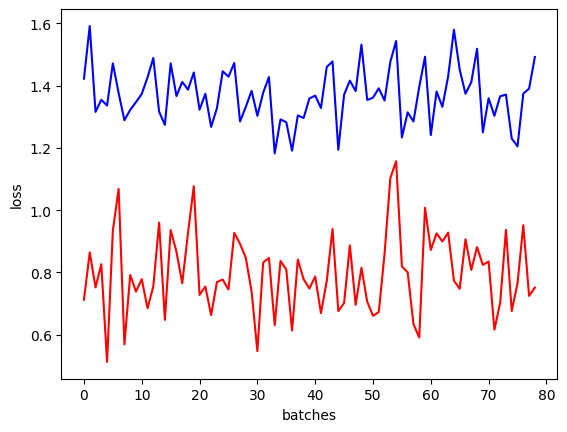

In [122]:
import numpy as np

#plt.xlim(0, 10)
#plt.ylim(2, 2.5)
plt.plot(np.arange(len(losses_res)),losses_res,label="resnet", color='r')

plt.plot(np.arange(len(losses_base)),losses_base,label="base", color='b')

plt.xlabel('batches')
plt.ylabel('loss')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

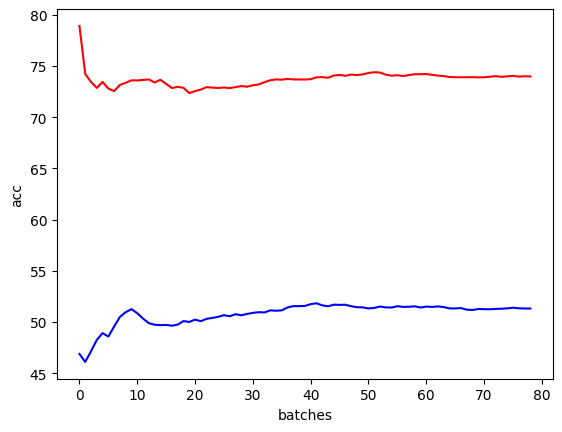

In [123]:
import numpy as np
plt.plot(np.arange(len(accs_res)),accs_res,label="resnet", color='r')

plt.plot(np.arange(len(accs_base)),accs_base,label="base", color='b')

plt.xlabel('batches')
plt.ylabel('acc')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

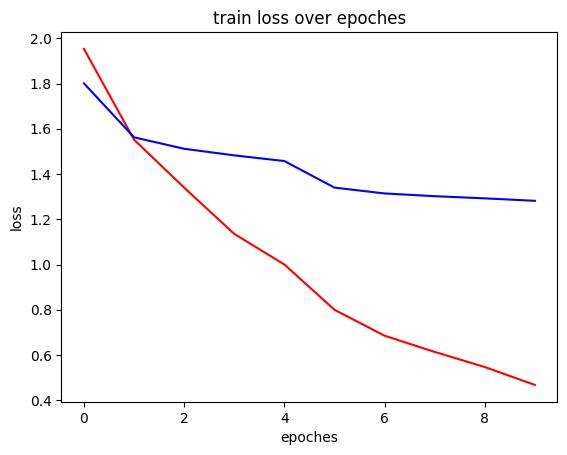

In [126]:
import numpy as np
plt.plot(np.arange(len(train_loss)),train_loss,label="resnet", color='r')

plt.plot(np.arange(len(train_loss_base)),train_loss_base,label="base", color='b')

plt.title('train loss over epoches')
plt.xlabel('epoches')
plt.ylabel('loss')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

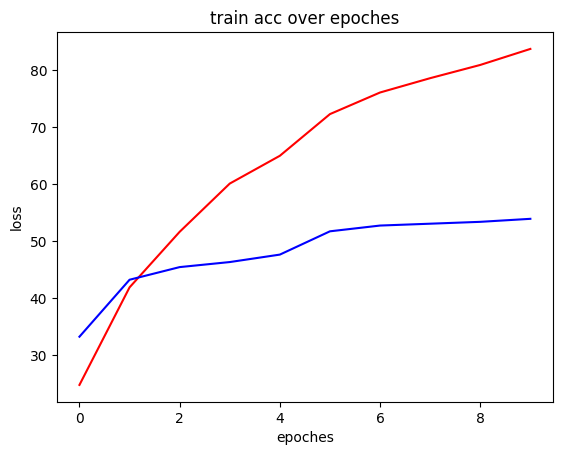

In [127]:
import numpy as np
plt.plot(np.arange(len(train_accs)),train_accs,label="resnet", color='r')

plt.plot(np.arange(len(train_accs_base)),train_accs_base,label="base", color='b')

plt.title('train acc over epoches')
plt.xlabel('epoches')
plt.ylabel('loss')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

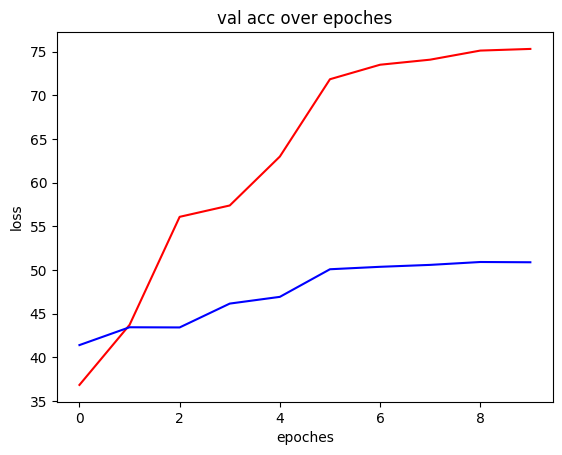

In [128]:
import numpy as np
plt.plot(np.arange(len(val_accs)),val_accs,label="resnet", color='r')

plt.plot(np.arange(len(val_accs_base)),val_accs_base,label="base", color='b')

plt.title('val acc over epoches')
plt.xlabel('epoches')
plt.ylabel('loss')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

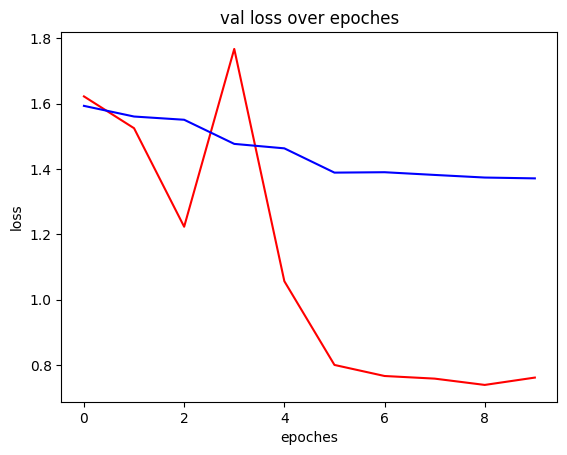

In [129]:
import numpy as np
plt.plot(np.arange(len(val_loss)),val_loss,label="resnet", color='r')

plt.plot(np.arange(len(val_loss_base)),val_loss_base,label="base", color='b')

plt.title('val loss over epoches')
plt.xlabel('epoches')
plt.ylabel('loss')

plt.show